In [33]:
import plotly.express as px
import pandas as pd

categories = ['PTB-XL', 'CPSC2018', 'MIT-BIH', 'Sleep Apnea', 'LVEF', 'PPG', 'Exercise']

data = {
    'PTB-XL':             [0.930, 0.923, 0.931, 0.928, 0.927, 0.873],
    'CPSC2018':           [0.962, 0.966, 0.973, 0.918, 0.979, 0.941],
    'MIT-BIH':            [0.588, 0.513, 0.408, 0.532, 0.620, 0.398],
    'Sleep Apnea':        [0.718, 0.605, 0.642, 0.721, 0.942, 0.765],
    'LVEF':               [7.67, 7.49, 7.29, 7.42, 6.91, 6.96],
    'PPG':                [0.695, 0.832, 0.865, 0.857, 0.908, 0.878],
    'Exercise':           [0.986, 0.986, 0.082, 0.929, 0.972, 0.963]
}

methods = ['ST-MEM', 'ECG-JEPA', 'ECG Founder', 'ours (transformer)', 'ours(xlstm)', 'supervised(xlstm)']

df_raw = pd.DataFrame(data, index=methods)
df_raw.head()

,PTB-XL,CPSC2018,MIT-BIH,Sleep Apnea,LVEF,PPG,Exercise
ST-MEM,0.930,0.962,0.588,0.718,7.67,0.695,0.986
ECG-JEPA,0.923,0.966,0.513,0.605,7.49,0.832,0.986
ECG Founder,0.931,0.973,0.408,0.642,7.29,0.865,0.082
ours (transformer),0.928,0.918,0.532,0.721,7.42,0.857,0.929
ours(xlstm),0.927,0.979,0.620,0.942,6.91,0.908,0.972


In [34]:
df_raw.mean(axis=0)

PTB-XL         0.918667
CPSC2018       0.956500
MIT-BIH        0.509833
Sleep Apnea    0.732167
LVEF           7.290000
PPG            0.839167
Exercise       0.819667
dtype: float64

In [35]:
df_raw - df_raw.mean(axis=0)

,PTB-XL,CPSC2018,MIT-BIH,Sleep Apnea,LVEF,PPG,Exercise
ST-MEM,0.011333,0.0055,0.078167,-0.014167,0.38,-0.144167,0.166333
ECG-JEPA,0.004333,0.0095,0.003167,-0.127167,0.20,-0.007167,0.166333
ECG Founder,0.012333,0.0165,-0.101833,-0.090167,0.00,0.025833,-0.737667
ours (transformer),0.009333,-0.0385,0.022167,-0.011167,0.13,0.017833,0.109333
ours(xlstm),0.008333,0.0225,0.110167,0.209833,-0.38,0.068833,0.152333
supervised(xlstm),-0.045667,-0.0155,-0.111833,0.032833,-0.33,0.038833,0.143333


In [36]:
# df_raw['LVEF'] = df_raw['LVEF'].max() - df_raw['LVEF'] + 0.2

df_z_scaled = df_raw.copy()
df_z_scaled = (df_z_scaled - df_z_scaled.mean(axis=0)) / df_z_scaled.std(axis=0)
df_z_scaled['LVEF'] = df_z_scaled['LVEF'] * -1  # Invert LVEF for better visualization

#df_raw["LVEF"] = df_raw["LVEF"] / df_raw["LVEF"].max()
df_raw.head()
print(df_z_scaled)

                      PTB-XL  CPSC2018   MIT-BIH  Sleep Apnea      LVEF  \
ST-MEM              0.502703  0.240200  0.856703    -0.119958 -1.260242   
ECG-JEPA            0.192210  0.414891  0.034707    -1.076796 -0.663285   
ECG Founder         0.547060  0.720600 -1.116089    -0.763495 -0.000000   
ours (transformer)  0.413991 -1.681399  0.242946    -0.094555 -0.431135   
ours(xlstm)         0.369635  0.982636  1.207422     1.776784  1.260242   
supervised(xlstm)  -2.025599 -0.676927 -1.225688     0.278019  1.094421   

                         PPG  Exercise  
ST-MEM             -1.924213  0.459495  
ECG-JEPA           -0.095655  0.459495  
ECG Founder         0.344801 -2.037801  
ours (transformer)  0.238024  0.302033  
ours(xlstm)         0.918728  0.420820  
supervised(xlstm)   0.518314  0.395958  


In [37]:
import pandas as pd
from plotly.subplots import make_subplots
import plotly.graph_objects as go

categories_closed = categories + [categories[0]]

fig = go.Figure()
# Plot one radar chart for each method on separate axes (subplots)

min_v = df_z_scaled.min().min()
max_v = df_z_scaled.max().max()
print(f"Min value: {min_v}, Max value: {max_v}")

num_methods = len(df_z_scaled)
fig = make_subplots(
    rows=1, cols=num_methods,
    specs=[[{'type': 'polar'}]*(num_methods)],
    subplot_titles=df_z_scaled.index.tolist()
)

for i, (idx, row) in enumerate(df_z_scaled.iterrows()):
    #if i == len(df_z_scaled) -1:
    #    continue
    values = row.tolist() + [row.tolist()[0]]  # close the loop
    trace = fig.add_trace(
        go.Scatterpolar(
            r=values,
            theta=categories_closed,
            fill='toself',
            name=idx,
            line=dict(width=3),
            hoverinfo='skip',
        ),
        row=1, col=i+1
    )
    print(row.min(), row.max())
    trace.update_polars(
        radialaxis=dict(visible=True, range=[min_v, max_v], showticklabels=False, showline=False),
        # angularaxis=dict(showticklabels=False)
    )

fig.update_layout(#
    showlegend=False,
#    title="Radar Chart for Each Method",
)

# save pdf
fig.write_image("radar_chart_methods.pdf", width=1200, height=600)
fig.show()

Min value: -2.0378009116219435, Max value: 1.7767838508099936
-1.9242130308850176 0.8567031045254085
-1.076795931825278 0.4594950993670811
-2.0378009116219435 0.7205995977506959
-1.6813990614182937 0.4139910595794081
0.36963487462447137 1.7767838508099936
-2.0255991129421136 1.0944205175560677


In [38]:
import pandas as pd
from plotly.subplots import make_subplots
import plotly.graph_objects as go

categories_closed = categories + [categories[0]]

fig = go.Figure()
# Plot one radar chart for each method on separate axes (subplots)

num_methods = len(df_raw)
fig = make_subplots(
    rows=1, cols=num_methods,
    specs=[[{'type': 'polar'}]*num_methods],
    subplot_titles=df_raw.index.tolist()
)

for i, (idx, row) in enumerate(df_raw.iterrows()):
    values = row.tolist() + [row.tolist()[0]]  # close the loop
    trace = fig.add_trace(
        go.Scatterpolar(
            r=values,
            theta=categories_closed,
            fill='toself',
            name=idx,
            line=dict(width=2),
            hoverinfo='skip',
        ),
        row=1, col=i+1
    )
    trace.update_polars(
        radialaxis=dict(visible=True, range=[0., 1], showticklabels=False, showline=False),
        # angularaxis=dict(showticklabels=False)
    )

fig.update_layout(
    showlegend=False,
    title="Radar Chart for Each Method",
)
fig.show()

In [39]:
df_scaled = df_raw.copy()
df_scaled = ((df_raw - df_raw.min()) / (df_raw.max() - df_raw.min()))
#df_scaled = ((df_raw - 0.5) / (df_raw.max()))
df_scaled['LVEF'] = 1 - df_scaled['LVEF']
df_scaled.head()

,PTB-XL,CPSC2018,MIT-BIH,Sleep Apnea,LVEF,PPG,Exercise
ST-MEM,0.982759,0.721311,0.855856,0.335312,0.000000,0.000000,1.000000
ECG-JEPA,0.862069,0.786885,0.518018,0.000000,0.236842,0.643192,1.000000
ECG Founder,1.000000,0.901639,0.045045,0.109792,0.500000,0.798122,0.000000
ours (transformer),0.948276,0.000000,0.603604,0.344214,0.328947,0.760563,0.936947
ours(xlstm),0.931034,1.000000,1.000000,1.000000,1.000000,1.000000,0.984513


In [40]:
import pandas as pd
import plotly.graph_objects as go

categories_closed = categories + [categories[0]]

fig = go.Figure()

for idx, row in df_scaled.iterrows():
    values = row.tolist() + [row.tolist()[0]]  # close the loop
    fig.add_trace(go.Scatterpolar(
        r=values,
        theta=categories_closed,
        fill='toself',
        name=idx,
        line=dict(width=2)
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(visible=True, range=[0, 1])
    ),
    showlegend=True,
    title="Scaled Radar Chart (LVEF Inverted)"
)

fig.show()

In [41]:
import pandas as pd
from plotly.subplots import make_subplots
import plotly.graph_objects as go

categories_closed = categories + [categories[0]]

fig = go.Figure()
# Plot one radar chart for each method on separate axes (subplots)


num_methods = len(df_raw)
fig = make_subplots(
    rows=1, cols=num_methods,
    specs=[[{'type': 'polar'}]*num_methods],
    subplot_titles=df_scaled.index.tolist()
)

for i, (idx, row) in enumerate(df_scaled.iterrows()):
    values = row.tolist() + [row.tolist()[0]]  # close the loop
    trace = fig.add_trace(
        go.Scatterpolar(
            r=values,
            theta=categories_closed,
            fill='toself',
            name=idx,
            line=dict(width=2),
            hoverinfo='skip',
        ),
        row=1, col=i+1
    )
    trace.update_polars(
        radialaxis=dict(visible=True, range=[-0.1, 1], showticklabels=False, showline=False),
        # angularaxis=dict(showticklabels=False)
    )

fig.update_layout(
    showlegend=False,
    title="Radar Chart for Each Method",
)
fig.show()

In [42]:
import numpy as np
data_ranked = {
    k: np.argsort(np.argsort(v)[::-1]) for k, v in data.items()
}
data_ranked

{'PTB-XL': array([1, 4, 0, 2, 3, 5]),
 'CPSC2018': array([3, 2, 1, 5, 0, 4]),
 'MIT-BIH': array([1, 3, 4, 2, 0, 5]),
 'Sleep Apnea': array([3, 5, 4, 2, 0, 1]),
 'LVEF': array([0, 1, 3, 2, 5, 4]),
 'PPG': array([5, 4, 2, 3, 0, 1]),
 'Exercise': array([1, 0, 5, 4, 2, 3])}

In [50]:
df_ranked = df_raw.copy()
for dataset in df_ranked.columns:
    df_ranked.loc[:, dataset] = len(df_ranked) - np.argsort(np.argsort(df_ranked.loc[:, dataset]))
df_ranked['LVEF'] = len(df_ranked) - df_ranked['LVEF'] + 1

In [51]:
df_ranked.mean(axis=1)

ST-MEM                3.714286
ECG-JEPA              4.142857
ECG Founder           3.571429
ours (transformer)    4.000000
ours(xlstm)           1.714286
supervised(xlstm)     3.857143
dtype: float64

In [52]:
import pandas as pd
from plotly.subplots import make_subplots
import plotly.graph_objects as go

categories_closed = categories + [categories[0]]

fig = go.Figure()
# Plot one radar chart for each method on separate axes (subplots)

num_methods = len(df_ranked)
fig = make_subplots(
    rows=1, cols=num_methods,
    specs=[[{'type': 'polar'}]*num_methods],
    subplot_titles=df_ranked.index.tolist()
)

for i, (idx, row) in enumerate((len(df_ranked) - df_ranked).iterrows()):
    values = row.tolist() + [row.tolist()[0]]  # close the loop
    trace = fig.add_trace(
        go.Scatterpolar(
            r=values,
            theta=categories_closed,
            fill='toself',
            name=idx,
            line=dict(width=2),
            hoverinfo='skip',
        ),
        row=1, col=i+1
    )
    trace.update_polars(
        radialaxis=dict(visible=True, range=[-1, len(df_ranked)], showticklabels=False, showline=False),
        # angularaxis=dict(showticklabels=False)
    )

fig.update_layout(
    showlegend=False,
    title="Radar Chart for Each Method",
)
fig.show()

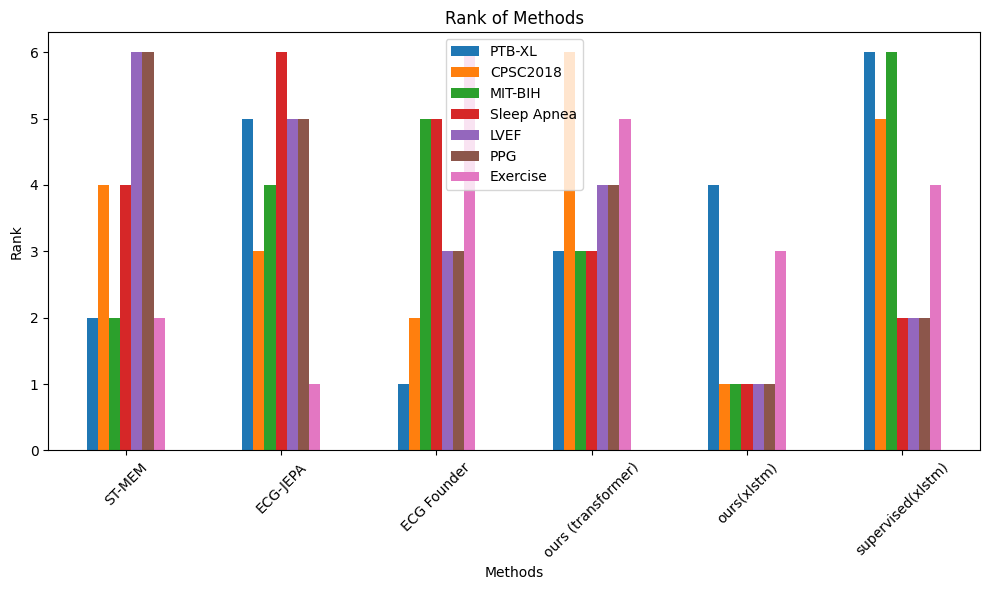

In [53]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
df_ranked.plot(kind='bar', ax=ax, legend=False)
plt.xticks(rotation=45)
ax.set_xticklabels(methods, rotation=45)
plt.xlabel('Methods')
plt.ylabel('Rank')
plt.title('Rank of Methods')
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_339879/2596381787.py:12: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



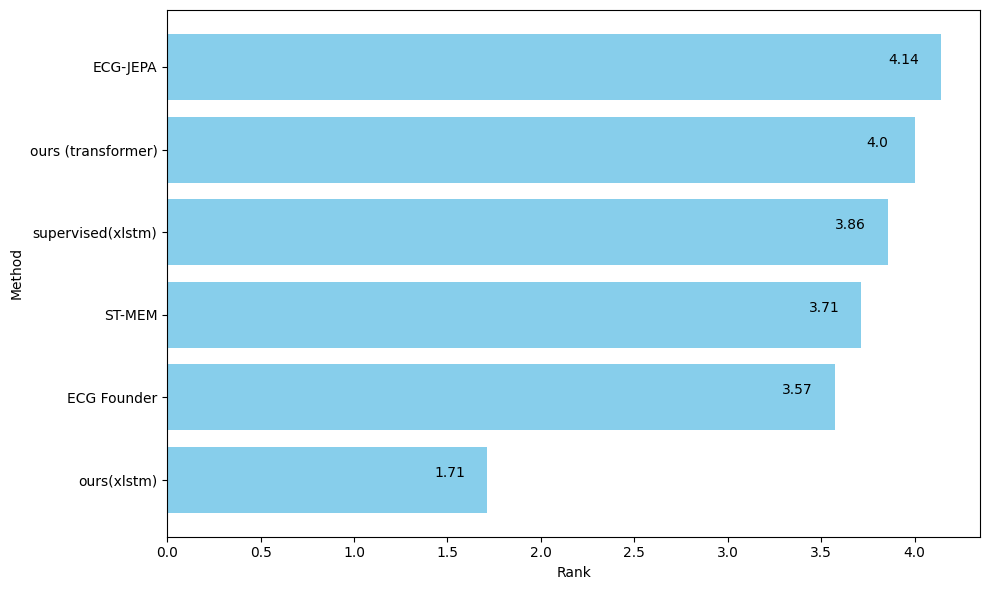

In [54]:
import matplotlib.pyplot as plt
df_ranked_sorted = df_ranked.copy()
df_ranked_sorted["mean_rank"] = df_ranked.mean(axis=1)
df_ranked_sorted = df_ranked_sorted.sort_values(by="mean_rank", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
# horizontal bar plot
ax.barh(df_ranked_sorted.index, df_ranked_sorted["mean_rank"], color='skyblue')
# add label to each bar
for i, v in enumerate(df_ranked_sorted["mean_rank"]):
    ax.text(v - 0.2, i, str(round(v, 2)), ha='center', va='bottom')
ax.set_yticklabels(df_ranked_sorted.index)
plt.xlabel('Rank')
plt.ylabel('Method')
plt.tight_layout()
plt.show()

In [48]:
df_ranked_r = len(df_ranked) - df_ranked
df_ranked_r.head()

,PTB-XL,CPSC2018,MIT-BIH,Sleep Apnea,LVEF,PPG,Exercise
ST-MEM,4.0,2.0,4.0,2.0,1.0,0.0,4.0
ECG-JEPA,1.0,3.0,2.0,0.0,2.0,1.0,5.0
ECG Founder,5.0,4.0,1.0,1.0,4.0,3.0,0.0
ours (transformer),3.0,0.0,3.0,3.0,3.0,2.0,1.0
ours(xlstm),2.0,5.0,5.0,5.0,6.0,5.0,3.0


In [49]:

categories_closed = categories + [categories[0]]

fig = go.Figure()

for idx, row in df_ranked_r.iterrows():
    values = row.tolist() + [row.tolist()[0]]  # close the loop
    fig.add_trace(go.Scatterpolar(
        r=values,
        theta=categories_closed,
        fill='toself',
        name=idx,
        line=dict(width=2)
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(visible=False, range=[-1, 4])
    ),
    showlegend=True,
    title="Rank Radar Chart"
)

fig.show()